# Feature Group Delta Analysis
# All feature-group combinations (power set) over BASE

## 1 · Config & Imports

In [1]:
import re
import pandas as pd
import numpy as np
import time
import warnings
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")

from itertools import product as iterproduct, combinations
from sklearn.ensemble import (
    RandomForestRegressor, HistGradientBoostingRegressor,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── plot theme ──
plt.rcParams.update({
    "figure.facecolor": "#0a0e17",
    "axes.facecolor":   "#111827",
    "axes.edgecolor":   "#1e293b",
    "axes.labelcolor":  "#9ca3af",
    "xtick.color":      "#6b7280",
    "ytick.color":      "#6b7280",
    "text.color":       "#e2e8f0",
    "grid.color":       "#1e293b",
    "font.family":      "monospace",
    "font.size":        10,
})
AMBER  = "#f0b429"
BLUE   = "#60a5fa"
GREEN  = "#10b981"
RED    = "#ef4444"
PURPLE = "#a78bfa"
CYAN   = "#22d3ee"
PINK   = "#f472b6"
GRAY   = "#4a5568"

# ── config ──
TEST_SIZE    = 0.30
RANDOM_STATE = 42
FILL_VALUE   = -999


/Users/Rohanchoudhary/Desktop/projs/genie_stocks/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2 · Data Load & Ops Merge

In [2]:
df = pd.read_hdf("../reports/test_scored.h5", "df")
print(f"Shape before ops merge: {df.shape}")

# ── MERGE PARTNER OPS (TRAIN window — leak-free) ──
df_ops_train = pd.read_csv("../reports/partner_ops_train_vector.csv")
print(f"Ops train: {df_ops_train.shape}")

TEMPORAL_WINDOWS = sorted([
    int(c.replace("se_", "").replace("d", ""))
    for c in df_ops_train.columns
    if re.match(r"^se_\d+d$", c) and "delta" not in c
])
print(f"Temporal windows detected: {TEMPORAL_WINDOWS}")

smallest_wd = min(TEMPORAL_WINDOWS)
rf_ops_cols = ["partner_id"]
for wd in TEMPORAL_WINDOWS:
    rf_ops_cols += [f"se_{wd}d", f"decline_rate_{wd}d", f"median_response_min_{wd}d"]
    if wd != smallest_wd:
        rf_ops_cols += [
            f"se_delta_{smallest_wd}_{wd}",
            f"decline_rate_delta_{smallest_wd}_{wd}",
            f"response_delta_{smallest_wd}_{wd}",
        ]
rf_ops_cols += [
    "queue_velocity", "plan_created_rate", "active_tickets",
    "nmbr_active_leads", "expected_daily_slots", "has_shock",
]
rf_ops_cols = [c for c in rf_ops_cols if c in df_ops_train.columns]

df["partner_id"] = df["partner_id"].astype(str)
df_ops_train["partner_id"] = df_ops_train["partner_id"].astype(str)
df = df.merge(df_ops_train[rf_ops_cols], on="partner_id", how="left", suffixes=("", "_ops"))
df = df.loc[:, ~df.columns.str.endswith("_ops")]
print(f"Shape after ops merge: {df.shape}")

_ops_feature_cols = [c for c in rf_ops_cols if c != "partner_id"]
print(f"Ops features merged: {len(_ops_feature_cols)}")


Shape before ops merge: (18082, 205)
Ops train: (1475, 43)
Temporal windows detected: [30, 60, 365]
Shape after ops merge: (18082, 224)
Ops features merged: 19


## 3 · Feature Group Definitions

**BASE**: the 35 static spatial/hex/contested/boundary/geometry/lead features currently used.

Three add-on groups — tested in **all 7 non-empty combinations** on top of BASE:
1. **temporal** — temporal field, temporal hex SE, temporal geometry, temporal contested
2. **partner_ops** — partner-level operational signals from train window
3. **neighbour_spatial** — hop-ring SE aggregates (static + temporal)

In [3]:
TARGET = "installed_decision"

# ═══════════════════════════════════════════════════
# BASE — the current 35-feature set
# ═══════════════════════════════════════════════════
BASE_FEATURES = [
    # Spatial — Gaussian KDE
    "predicted_field_hex",
    "n_overlapping_hexes_field",
    "contested_field",
    # Hex consensus
    "parent_se", "parent_total", "parent_color_numeric",
    "n_covering_partners", "parent_overlap",
    # Contested
    "contested_area_km2", "contested_radius_m", "contested_se",
    "n_overlapping_partners",
    # Boundary
    "dist_to_boundary_edge_point_hex", "dist_to_cluster_center_point_hex",
    "depth_score_point_hex", "mean_dist_to_edge_m", "mean_dist_to_center_m",
    "total_area_boundaries", "nmbr_overlap_clusters",
    "nearest_boundary_dist_m", "nmbr_boundaries_within_100m",
    "worst_depth_score", "any_near_edge", "is_solo_cluster",
    # Geometry
    "local_anisotropy", "local_density", "hull_area",
    "linearity_score", "spread_m",
    "dense_score", "gully_score", "sparse_score",
    # Lead-level
    "hard_density", "density_regime", "min_dist",
]

# ═══════════════════════════════════════════════════
# ADD-ON GROUP 1: Temporal features
# ═══════════════════════════════════════════════════
TEMPORAL_FEATURES = [
    # Temporal field
    "predicted_field_hex_30d", "predicted_field_hex_60d", "predicted_field_hex_365d",
    "field_momentum",
    # Temporal hex SE
    "weighted_se_30d_shrunk", "weighted_se_60d_shrunk", "weighted_se_365d_shrunk",
    "se_momentum",
    # Temporal geometry
    "local_density_30d", "local_density_60d", "local_density_365d",
    "dense_score_30d", "dense_score_60d", "dense_score_365d",
    "sparse_score_30d", "sparse_score_60d", "sparse_score_365d",
    "spread_m_30d", "spread_m_60d", "spread_m_365d",
    # Temporal contested
    "contested_se_30d", "contested_se_60d", "contested_se_365d",
]

# ═══════════════════════════════════════════════════
# ADD-ON GROUP 2: Partner ops features
# ═══════════════════════════════════════════════════
PARTNER_FEATURES = _ops_feature_cols  # already computed above

# ═══════════════════════════════════════════════════
# ADD-ON GROUP 3: Neighbour spatial (hop) features
# ═══════════════════════════════════════════════════
NEIGHBOUR_FEATURES = [
    # Static hop
    "hop1_se_wmean", "hop2_se_wmean", "hop3_se_wmean",
    "hop1_se_std",   "hop2_se_std",   "hop3_se_std",
    "hop1_count",    "hop2_count",    "hop3_count",
    "se_gradient_1to3", "se_confirmed", "isolation_ratio",
    # Temporal hop
    "hop1_se_30d_wmean",  "hop2_se_30d_wmean",  "hop3_se_30d_wmean",
    "hop1_se_60d_wmean",  "hop2_se_60d_wmean",  "hop3_se_60d_wmean",
    "hop1_se_365d_wmean", "hop2_se_365d_wmean", "hop3_se_365d_wmean",
    "se_gradient_1to3_30d",  "se_gradient_1to3_60d",  "se_gradient_1to3_365d",
    "se_confirmed_30d",      "se_confirmed_60d",      "se_confirmed_365d",
]

# ── filter to what's actually in df ──
base_avail      = [f for f in BASE_FEATURES      if f in df.columns]
temporal_avail  = [f for f in TEMPORAL_FEATURES   if f in df.columns]
partner_avail   = [f for f in PARTNER_FEATURES    if f in df.columns]
neighbour_avail = [f for f in NEIGHBOUR_FEATURES  if f in df.columns]

print(f"BASE features:      {len(base_avail)}/{len(BASE_FEATURES)} available")
print(f"TEMPORAL add-on:    {len(temporal_avail)}/{len(TEMPORAL_FEATURES)} available")
print(f"PARTNER OPS add-on: {len(partner_avail)}/{len(PARTNER_FEATURES)} available")
print(f"NEIGHBOUR add-on:   {len(neighbour_avail)}/{len(NEIGHBOUR_FEATURES)} available")

# ═══════════════════════════════════════════════════
# Build ALL non-empty subsets of {T, P, N} on top of BASE
# ═══════════════════════════════════════════════════
ADDON_GROUPS = {
    "temporal":    temporal_avail,
    "partner_ops": partner_avail,
    "neighbour":   neighbour_avail,
}

EXPERIMENTS = {"BASE": base_avail}

for r in range(1, len(ADDON_GROUPS) + 1):
    for combo in combinations(ADDON_GROUPS.items(), r):
        name = "BASE + " + " + ".join(k for k, _ in combo)
        feats = base_avail + [f for _, v in combo for f in v]
        EXPERIMENTS[name] = feats

print(f"\nTotal experiments: {len(EXPERIMENTS)}")
for name, feats in EXPERIMENTS.items():
    print(f"  {name:50s}  → {len(feats)} features")


BASE features:      35/35 available
TEMPORAL add-on:    23/23 available
PARTNER OPS add-on: 19/19 available
NEIGHBOUR add-on:   27/27 available

Total experiments: 8
  BASE                                                → 35 features
  BASE + temporal                                     → 58 features
  BASE + partner_ops                                  → 54 features
  BASE + neighbour                                    → 62 features
  BASE + temporal + partner_ops                       → 77 features
  BASE + temporal + neighbour                         → 85 features
  BASE + partner_ops + neighbour                      → 81 features
  BASE + temporal + partner_ops + neighbour           → 104 features


## 4 · Prep & Train/Test Split (shared across all experiments)

In [4]:
# Use BASE + ALL add-on columns to build a single split
all_feature_cols = list(set(base_avail + temporal_avail + partner_avail + neighbour_avail))

y = df[TARGET].copy()
mask = y.notna()

X_full = df.loc[mask, all_feature_cols].copy().fillna(FILL_VALUE)
y = y[mask]

print(f"Samples: {len(X_full)},  Total feature pool: {X_full.shape[1]},  Install rate: {y.mean():.4f}")

# SINGLE split — same rows for every experiment
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y.astype(int),
)
print(f"Train: {len(X_train_full)}  Test: {len(X_test_full)}")
print(f"Train SE: {y_train.mean():.4f}  Test SE: {y_test.mean():.4f}")


Samples: 18082,  Total feature pool: 104,  Install rate: 0.5794
Train: 12657  Test: 5425
Train SE: 0.5794  Test SE: 0.5794


## 5 · Correlation Analysis (before training)

For each add-on group, show:
1. Feature-vs-target correlations for the new features
2. High collinearity pairs **within** the new features
3. High collinearity pairs **between** new features and BASE features

In [5]:
def correlation_report(group_name, new_feats, base_feats, data, target):
    """Print correlation diagnostics for a feature group."""
    if not new_feats:
        print(f"\n{'='*70}")
        print(f"  {group_name}: no features available — skipping")
        return

    print(f"\n{'='*70}")
    print(f"  {group_name}: {len(new_feats)} features")
    print(f"{'='*70}")

    # 1) Feature → target correlation
    feat_target_corr = data[new_feats + [target]].corr()[target].drop(target).sort_values(ascending=False)
    print(f"\n  Feature → target correlation:")
    for feat, val in feat_target_corr.items():
        if pd.isna(val):
            print(f"      NaN   {feat:45s}  (constant or all-null)")
            continue
        bar = "█" * int(abs(val) * 200)
        sign = "+" if val >= 0 else "-"
        print(f"    {sign}{abs(val):.4f}  {feat:45s}  {bar}")

    # 2) Collinearity WITHIN new features
    if len(new_feats) > 1:
        corr_within = data[new_feats].corr()
        high_within = []
        for i in range(len(new_feats)):
            for j in range(i + 1, len(new_feats)):
                r = corr_within.iloc[i, j]
                if abs(r) > 0.7:
                    high_within.append((new_feats[i], new_feats[j], round(r, 3)))
        high_within.sort(key=lambda x: -abs(x[2]))
        print(f"\n  Collinear pairs WITHIN group (|r| > 0.7): {len(high_within)}")
        for a, b, r in high_within[:15]:
            print(f"    {r:+.3f}  {a}  <->  {b}")

    # 3) Collinearity BETWEEN new ↔ base
    if base_feats and new_feats:
        cross_corr = data[base_feats + new_feats].corr().loc[new_feats, base_feats]
        high_cross = []
        for nf in new_feats:
            for bf in base_feats:
                r = cross_corr.loc[nf, bf]
                if abs(r) > 0.7:
                    high_cross.append((nf, bf, round(r, 3)))
        high_cross.sort(key=lambda x: -abs(x[2]))
        print(f"\n  Collinear pairs NEW ↔ BASE (|r| > 0.7): {len(high_cross)}")
        for a, b, r in high_cross[:15]:
            print(f"    {r:+.3f}  {a}  <->  {b}")


data_for_corr = df.loc[mask].copy()

correlation_report("TEMPORAL",      temporal_avail,  base_avail, data_for_corr, TARGET)
correlation_report("PARTNER OPS",   partner_avail,   base_avail, data_for_corr, TARGET)
correlation_report("NEIGHBOUR HOP", neighbour_avail, base_avail, data_for_corr, TARGET)



  TEMPORAL: 23 features

  Feature → target correlation:
    +0.1856  contested_se_60d                               █████████████████████████████████████
    +0.1698  contested_se_365d                              █████████████████████████████████
    +0.1536  predicted_field_hex_60d                        ██████████████████████████████
    +0.1454  contested_se_30d                               █████████████████████████████
    +0.1450  predicted_field_hex_30d                        ████████████████████████████
    +0.1381  predicted_field_hex_365d                       ███████████████████████████
    +0.1367  weighted_se_60d_shrunk                         ███████████████████████████
    +0.1270  weighted_se_30d_shrunk                         █████████████████████████
    +0.1248  weighted_se_365d_shrunk                        ████████████████████████
    +0.0996  field_momentum                                 ███████████████████
    +0.0347  dense_score_60d                         

### 5b · Correlation Heatmap — add-on features vs target & top BASE features

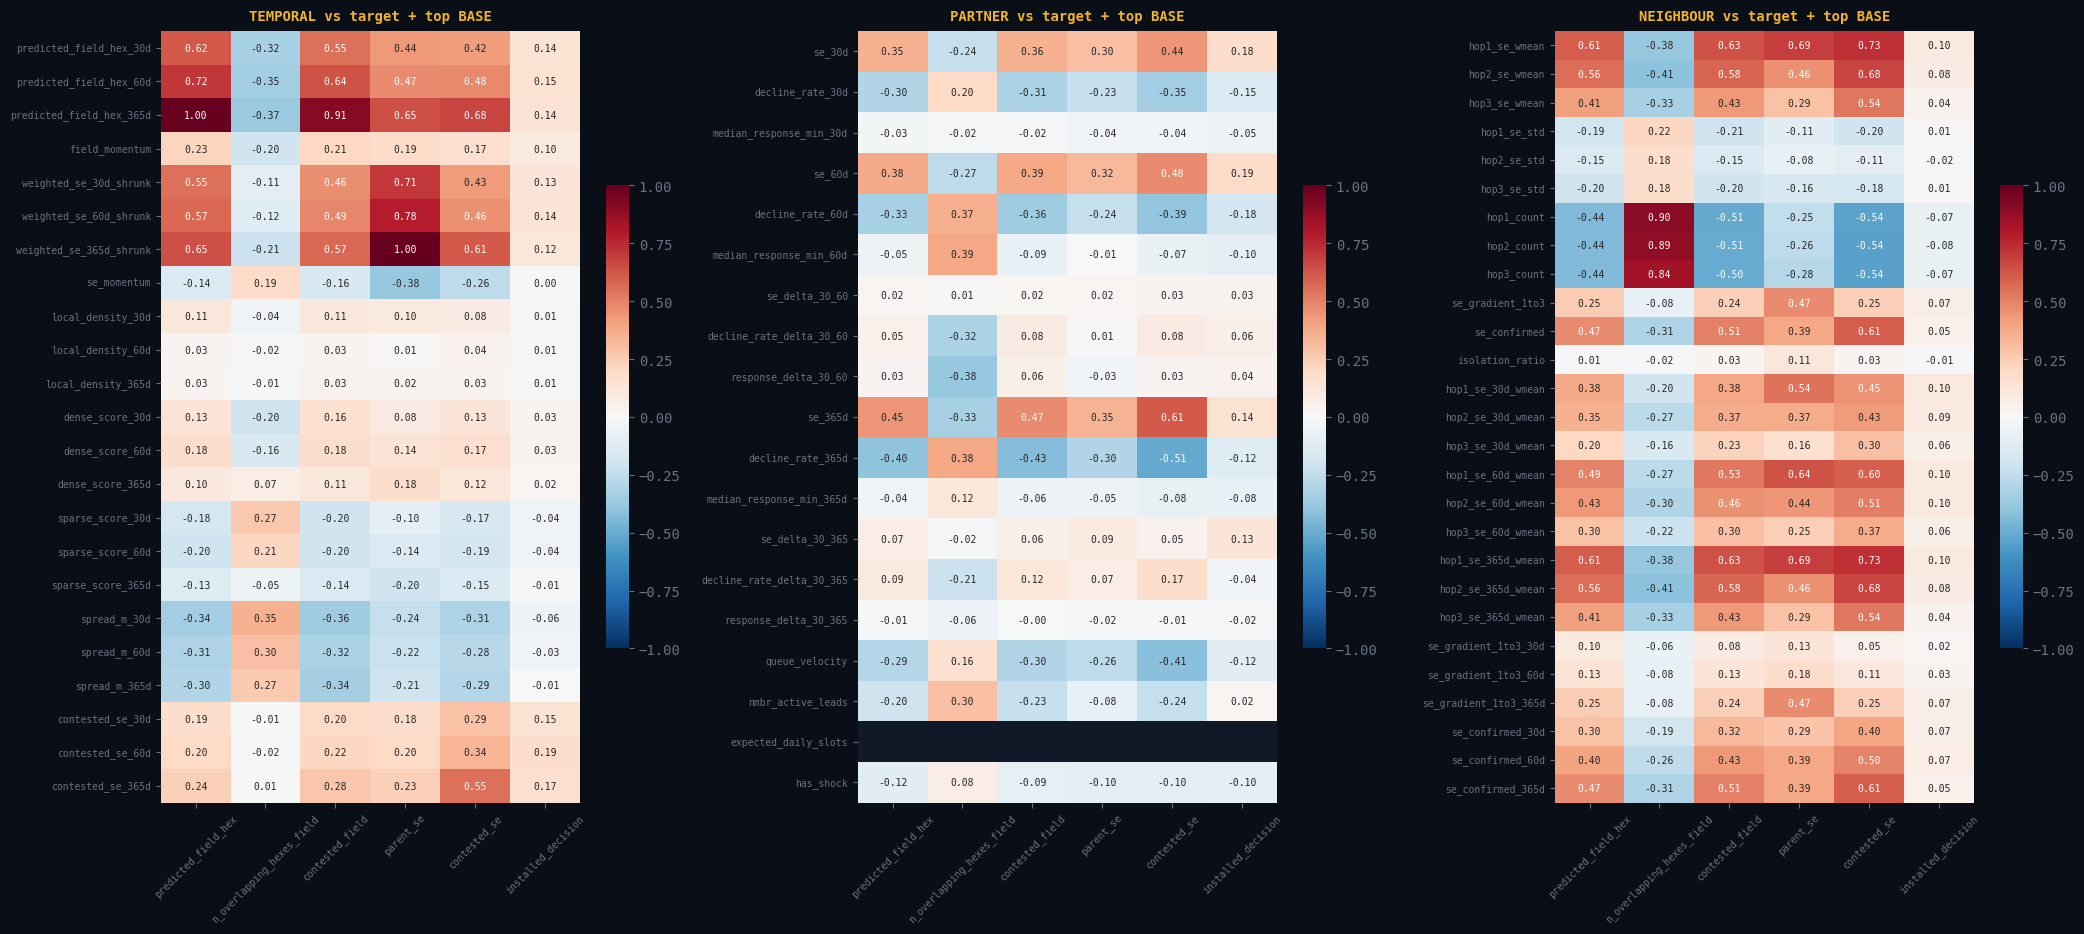

In [6]:
# Build a compact heatmap of each add-on group's correlation with target + top-5 BASE features
top_base = data_for_corr[base_avail + [TARGET]].corr()[TARGET].drop(TARGET).abs().nlargest(5).index.tolist()
addon_groups = {
    "temporal":  temporal_avail,
    "partner":   partner_avail,
    "neighbour": neighbour_avail,
}

n_panels = sum(1 for v in addon_groups.values() if v)
if n_panels > 0:
    fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, max(8, max(len(v) for v in addon_groups.values() if v) * 0.35)))
    if n_panels == 1:
        axes = [axes]
    ax_idx = 0
    for gname, gfeats in addon_groups.items():
        if not gfeats:
            continue
        ref_cols = top_base + [TARGET]
        corr_sub = data_for_corr[gfeats + ref_cols].corr().loc[gfeats, ref_cols]
        ax = axes[ax_idx]
        sns.heatmap(corr_sub, annot=True, fmt=".2f", center=0,
                    cmap="RdBu_r", vmin=-1, vmax=1,
                    ax=ax, cbar_kws={"shrink": 0.6},
                    annot_kws={"size": 7})
        ax.set_title(f"{gname.upper()} vs target + top BASE", fontsize=10, fontweight="bold", color=AMBER, pad=8)
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)
        ax_idx += 1
    plt.tight_layout()
    plt.show()
else:
    print("No add-on features available for heatmap.")


## 6 · Evaluation Utility

In [7]:
def eval_model(model, X_tr, y_tr, X_te, y_te):
    """Evaluate a fitted model. Returns dict with all metrics."""
    p_train = model.predict(X_tr)
    p_test  = model.predict(X_te)

    auc_train = roc_auc_score(y_tr, p_train)
    auc_test  = roc_auc_score(y_te, p_test)

    edf = pd.DataFrame({"y": y_te.values, "p": p_test})
    edf["decile"] = pd.qcut(edf["p"], q=10, labels=False, duplicates="drop") + 1
    tbl = edf.groupby("decile").agg(n=("y", "count"), inst=("y", "sum"))
    tbl["se"] = tbl["inst"] / tbl["n"]

    d1_se  = tbl["se"].iloc[0]
    d10_se = tbl["se"].iloc[-1]
    gap_pp = (d10_se - d1_se) * 100
    mono   = bool((tbl["se"].diff().dropna() >= 0).all())
    composite = auc_test * 100 + gap_pp

    return {
        "auc_train":  round(auc_train, 4),
        "auc_test":   round(auc_test, 4),
        "gap_pp":     round(gap_pp, 2),
        "d1_se":      round(d1_se, 4),
        "d10_se":     round(d10_se, 4),
        "mono":       mono,
        "composite":  round(composite, 2),
        "overfit_gap": round((auc_train - auc_test) * 100, 2),
    }


## 7 · Delta Experiment — all feature-group combinations

For each experiment config, train the best-known RF and HGB hyperparams (from the main notebook),
then record metrics. **No full sweep** — we fix hyperparams to isolate the feature-group effect.

In [8]:
# ── Fixed hyperparams (best from main notebook) ──
RF_PARAMS = dict(
    n_estimators=500, max_depth=16, min_samples_leaf=20,
    max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1,
)
HGB_PARAMS = dict(
    learning_rate=0.04, max_depth=4, min_samples_leaf=200,
    l2_regularization=2.0, max_leaf_nodes=63,
    loss="squared_error", max_iter=1000, max_bins=255,
    early_stopping=True, validation_fraction=0.15,
    n_iter_no_change=30, random_state=RANDOM_STATE,
)

results = []

for exp_name, feat_list in tqdm(EXPERIMENTS.items(), desc="Experiments"):
    print(f"\n{'─'*60}")
    print(f"  {exp_name}  ({len(feat_list)} features)")
    print(f"{'─'*60}")

    X_tr = X_train_full[feat_list].copy()
    X_te = X_test_full[feat_list].copy()

    # RF
    rf = RandomForestRegressor(**RF_PARAMS)
    rf.fit(X_tr, y_train)
    ev_rf = eval_model(rf, X_tr, y_train, X_te, y_test)
    print(f"  RF  — AUC_test: {ev_rf['auc_test']:.4f}  gap_pp: {ev_rf['gap_pp']:.2f}  "
          f"composite: {ev_rf['composite']:.2f}  overfit: {ev_rf['overfit_gap']:.1f}pp  mono: {ev_rf['mono']}")
    results.append({"experiment": exp_name, "model": "RF", "n_features": len(feat_list), **ev_rf})

    # HGB
    hgb = HistGradientBoostingRegressor(**HGB_PARAMS)
    hgb.fit(X_tr, y_train)
    ev_hgb = eval_model(hgb, X_tr, y_train, X_te, y_test)
    print(f"  HGB — AUC_test: {ev_hgb['auc_test']:.4f}  gap_pp: {ev_hgb['gap_pp']:.2f}  "
          f"composite: {ev_hgb['composite']:.2f}  overfit: {ev_hgb['overfit_gap']:.1f}pp  mono: {ev_hgb['mono']}")
    results.append({"experiment": exp_name, "model": "HGB", "n_features": len(feat_list), **ev_hgb})

results_df = pd.DataFrame(results)
print("\n" + "═" * 80)
print("  FULL RESULTS TABLE")
print("═" * 80)
print(results_df.to_string(index=False))


Experiments:   0%|          | 0/8 [00:00<?, ?it/s]


────────────────────────────────────────────────────────────
  BASE  (35 features)
────────────────────────────────────────────────────────────
  RF  — AUC_test: 0.6583  gap_pp: 53.04  composite: 118.87  overfit: 20.5pp  mono: True


Experiments:  12%|█▎        | 1/8 [00:01<00:12,  1.73s/it]

  HGB — AUC_test: 0.6531  gap_pp: 53.78  composite: 119.09  overfit: 6.0pp  mono: False

────────────────────────────────────────────────────────────
  BASE + temporal  (58 features)
────────────────────────────────────────────────────────────
  RF  — AUC_test: 0.6755  gap_pp: 58.01  composite: 125.56  overfit: 19.5pp  mono: True


Experiments:  25%|██▌       | 2/8 [00:03<00:11,  1.84s/it]

...

  HGB — AUC_test: 0.6768  gap_pp: 55.25  composite: 122.93  overfit: 4.1pp  mono: True

────────────────────────────────────────────────────────────
  BASE + partner_ops + neighbour  (81 features)
────────────────────────────────────────────────────────────
  RF  — AUC_test: 0.6952  gap_pp: 62.98  composite: 132.50  overfit: 18.9pp  mono: False


Experiments:  88%|████████▊ | 7/8 [00:14<00:02,  2.25s/it]

  HGB — AUC_test: 0.6868  gap_pp: 60.22  composite: 128.90  overfit: 6.4pp  mono: False

────────────────────────────────────────────────────────────
  BASE + temporal + partner_ops + neighbour  (104 features)
────────────────────────────────────────────────────────────
  RF  — AUC_test: 0.6957  gap_pp: 65.75  composite: 135.31  overfit: 19.6pp  mono: True


Experiments: 100%|██████████| 8/8 [00:17<00:00,  2.14s/it]

  HGB — AUC_test: 0.6872  gap_pp: 61.69  composite: 130.42  overfit: 6.7pp  mono: False

════════════════════════════════════════════════════════════════════════════════
  FULL RESULTS TABLE
════════════════════════════════════════════════════════════════════════════════
                               experiment model  n_features  auc_train  auc_test  gap_pp  d1_se  d10_se  mono  composite  overfit_gap
                                     BASE    RF          35     0.8633    0.6583   53.04 0.2431  0.7735  True     118.87        20.50
                                     BASE   HGB          35     0.7133    0.6531   53.78 0.2394  0.7772 False     119.09         6.01
                          BASE + temporal    RF          58     0.8709    0.6755   58.01 0.2247  0.8048  True     125.56        19.54
                          BASE + temporal   HGB          58     0.7260    0.6723   52.67 0.2523  0.7790  True     119.90         5.37
                       BASE + partner_ops    RF          5

## 8 · Delta Summary — incremental gains over BASE

In [9]:
# Compute deltas relative to BASE
base_rf  = results_df[(results_df["experiment"] == "BASE") & (results_df["model"] == "RF")].iloc[0]
base_hgb = results_df[(results_df["experiment"] == "BASE") & (results_df["model"] == "HGB")].iloc[0]

delta_rows = []
for _, row in results_df.iterrows():
    base = base_rf if row["model"] == "RF" else base_hgb
    delta_rows.append({
        "experiment":     row["experiment"],
        "model":          row["model"],
        "n_features":     row["n_features"],
        "auc_test":       row["auc_test"],
        "Δ_auc":          round(row["auc_test"]  - base["auc_test"], 4),
        "gap_pp":         row["gap_pp"],
        "Δ_gap_pp":       round(row["gap_pp"]    - base["gap_pp"], 2),
        "composite":      row["composite"],
        "Δ_composite":    round(row["composite"]  - base["composite"], 2),
        "overfit_gap":    row["overfit_gap"],
        "Δ_overfit":      round(row["overfit_gap"] - base["overfit_gap"], 2),
        "mono":           row["mono"],
    })

delta_df = pd.DataFrame(delta_rows)
print("═" * 120)
print("  DELTA TABLE — incremental gains over BASE")
print("═" * 120)
print(delta_df.to_string(index=False))


════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  DELTA TABLE — incremental gains over BASE
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
                               experiment model  n_features  auc_test  Δ_auc  gap_pp  Δ_gap_pp  composite  Δ_composite  overfit_gap  Δ_overfit  mono
                                     BASE    RF          35    0.6583 0.0000   53.04      0.00     118.87         0.00        20.50       0.00  True
                                     BASE   HGB          35    0.6531 0.0000   53.78      0.00     119.09         0.00         6.01       0.00 False
                          BASE + temporal    RF          58    0.6755 0.0172   58.01      4.97     125.56         6.69        19.54      -0.96  True
                          BASE + temporal   HGB          58    0.6723 0.0192   52.67     -1.11     119.90         0.81

### 8b · Delta Visualization

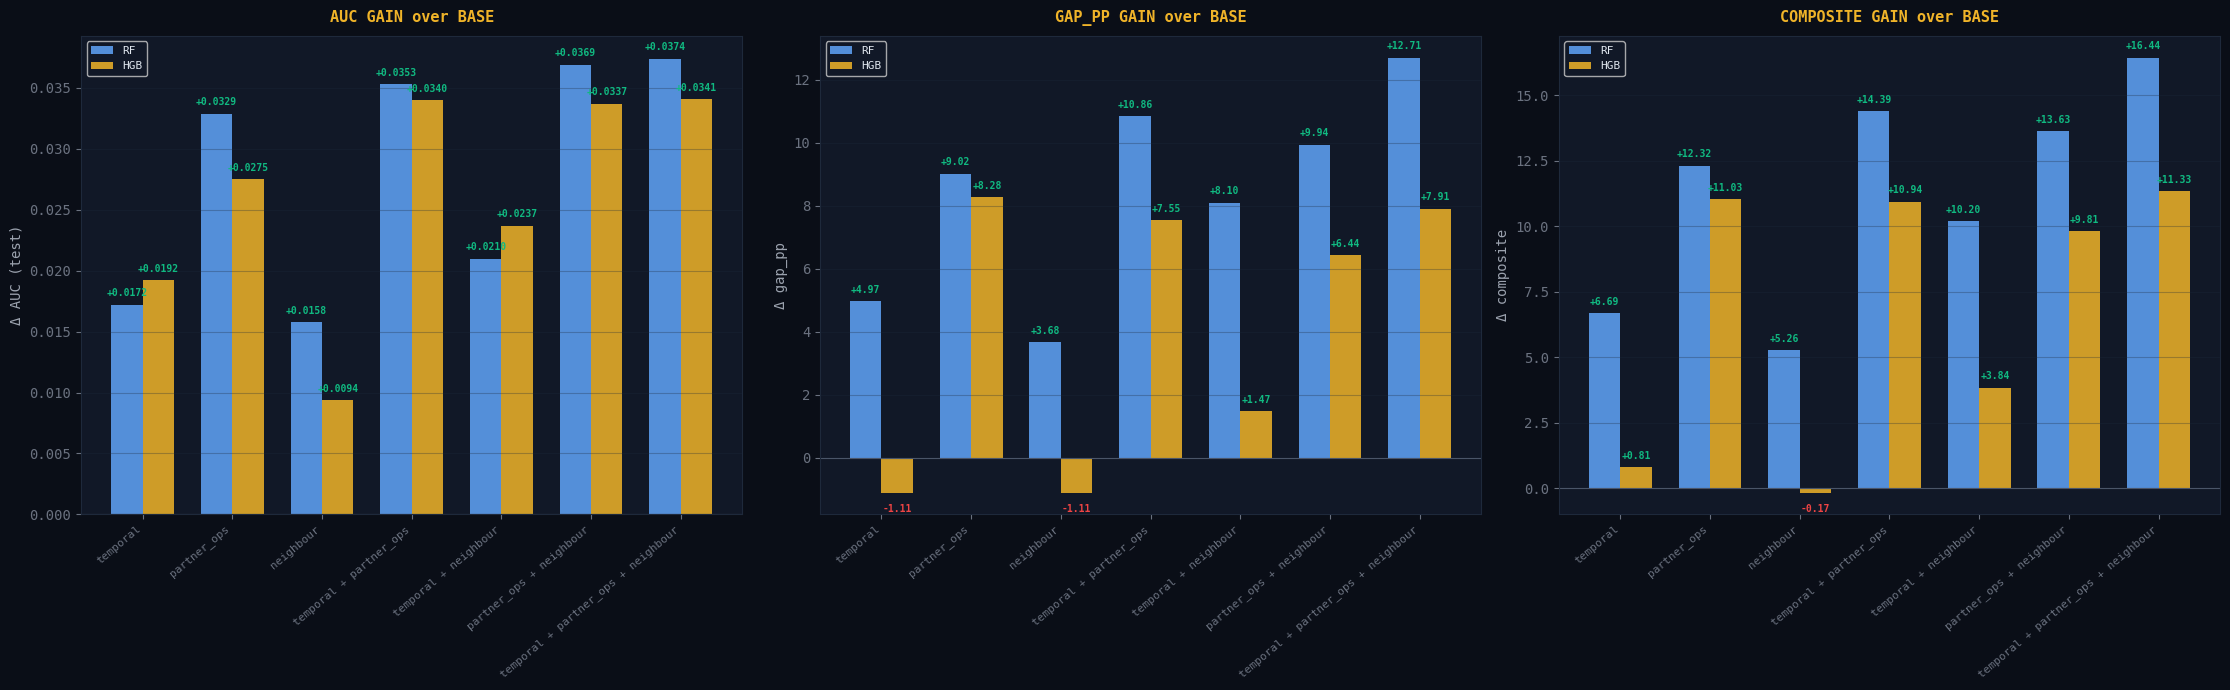

In [10]:
addon_exps = [e for e in EXPERIMENTS if e != "BASE"]
n_exp = len(addon_exps)

fig, axes = plt.subplots(1, 3, figsize=(max(18, n_exp * 3.2), 7))
x = np.arange(n_exp)
bar_w = 0.35

for ax, metric, ylabel, title in [
    (axes[0], "Δ_auc",       "Δ AUC (test)",       "AUC GAIN over BASE"),
    (axes[1], "Δ_gap_pp",    "Δ gap_pp",            "GAP_PP GAIN over BASE"),
    (axes[2], "Δ_composite", "Δ composite",          "COMPOSITE GAIN over BASE"),
]:
    for i, model_name, color, offset in [
        (0, "RF",  BLUE,  -bar_w/2),
        (1, "HGB", AMBER, +bar_w/2),
    ]:
        vals = []
        for exp in addon_exps:
            row = delta_df[(delta_df["experiment"] == exp) & (delta_df["model"] == model_name)]
            vals.append(row[metric].values[0] if len(row) else 0)
        bars = ax.bar(x + offset, vals, bar_w, label=model_name, color=color, alpha=0.85, edgecolor="none")
        for j, v in enumerate(vals):
            color_txt = GREEN if v > 0 else RED
            ax.annotate(f"{v:+.4f}" if "auc" in metric else f"{v:+.2f}",
                        xy=(x[j] + offset, v),
                        xytext=(0, 6 if v >= 0 else -14),
                        textcoords="offset points",
                        ha="center", fontsize=7, color=color_txt, fontweight="bold")

    ax.set_xticks(x)
    # Shorter labels: strip 'BASE + ' prefix
    short_labels = [e.replace("BASE + ", "") for e in addon_exps]
    ax.set_xticklabels(short_labels, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11, fontweight="bold", color=AMBER, pad=10)
    ax.axhline(0, color=GRAY, linewidth=0.8)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 9 · ROC Curves — all experiments

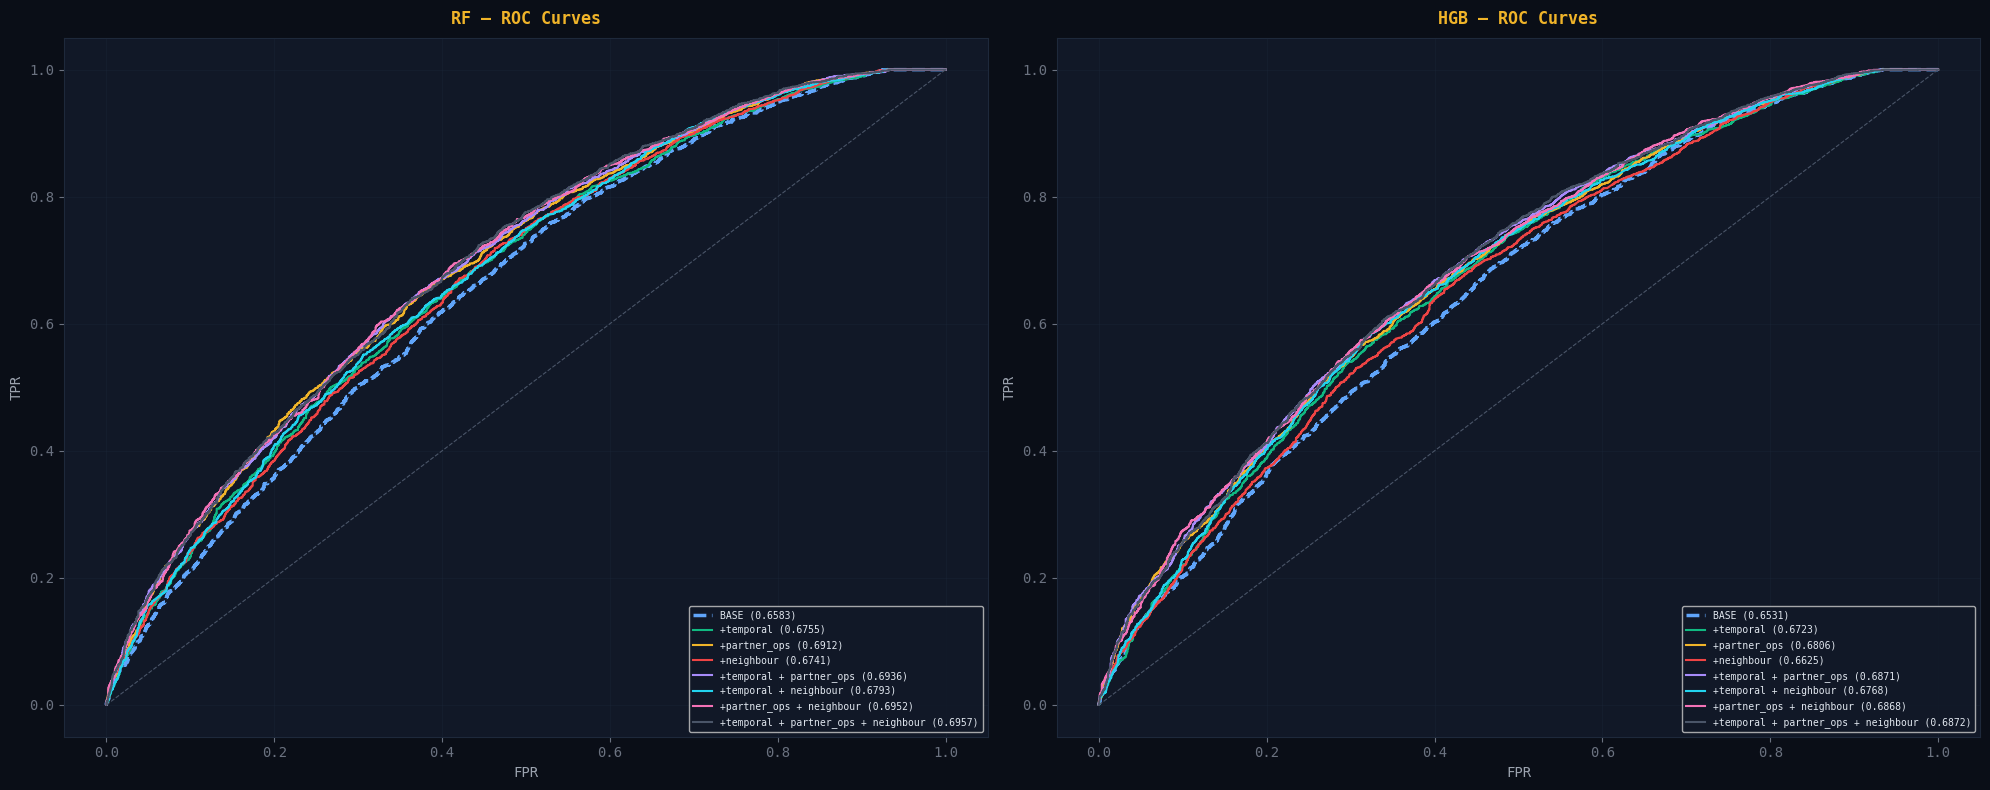

In [11]:
from sklearn.metrics import roc_curve, auc as sk_auc

n_models = 2  # RF, HGB
fig, axes = plt.subplots(1, n_models, figsize=(10 * n_models, 8))

# Colour palette for experiments
exp_colors = [BLUE, GREEN, AMBER, RED, PURPLE, CYAN, PINK, GRAY]

for ax, model_name in zip(axes, ["RF", "HGB"]):
    for idx, (exp_name, feat_list) in enumerate(EXPERIMENTS.items()):
        row = results_df[(results_df["experiment"] == exp_name) & (results_df["model"] == model_name)].iloc[0]

        # Refit quickly to get predictions for ROC
        if model_name == "RF":
            mdl = RandomForestRegressor(**RF_PARAMS)
        else:
            mdl = HistGradientBoostingRegressor(**HGB_PARAMS)
        mdl.fit(X_train_full[feat_list], y_train)
        p_test = mdl.predict(X_test_full[feat_list])

        fpr, tpr, _ = roc_curve(y_test, p_test)
        roc_auc_val = sk_auc(fpr, tpr)

        lw = 2.5 if exp_name == "BASE" else 1.5
        ls = "--" if exp_name == "BASE" else "-"
        c = exp_colors[idx % len(exp_colors)]
        short = exp_name.replace("BASE + ", "+") if exp_name != "BASE" else "BASE"
        ax.plot(fpr, tpr, color=c, lw=lw, ls=ls, label=f"{short} ({roc_auc_val:.4f})")

    ax.plot([0, 1], [0, 1], "--", color=GRAY, lw=0.8)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.set_title(f"{model_name} — ROC Curves", fontsize=12, fontweight="bold", color=AMBER, pad=10)
    ax.legend(fontsize=7, loc="lower right")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 10 · Feature Importance — new features in each combo

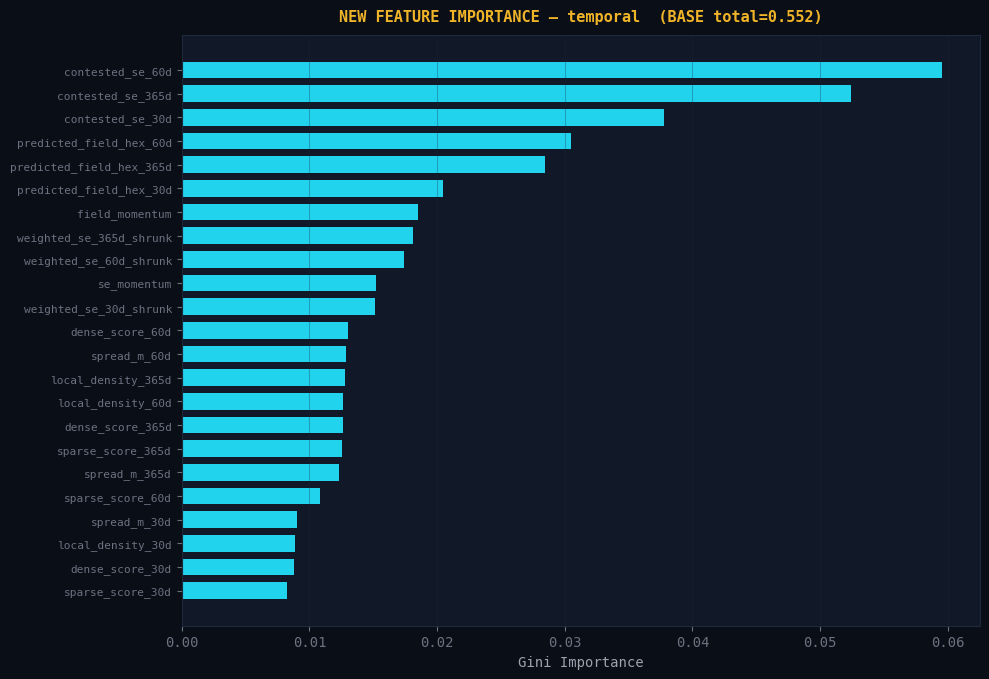

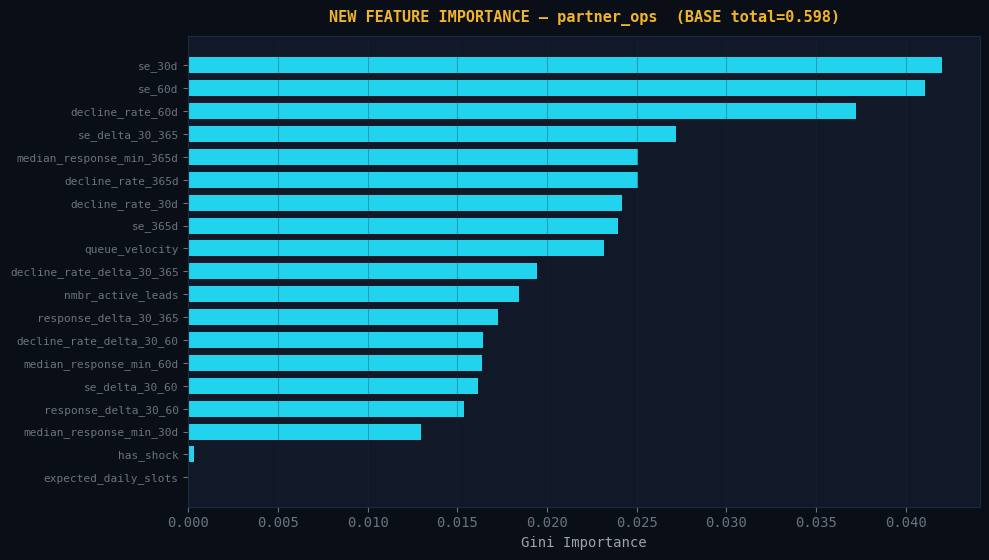

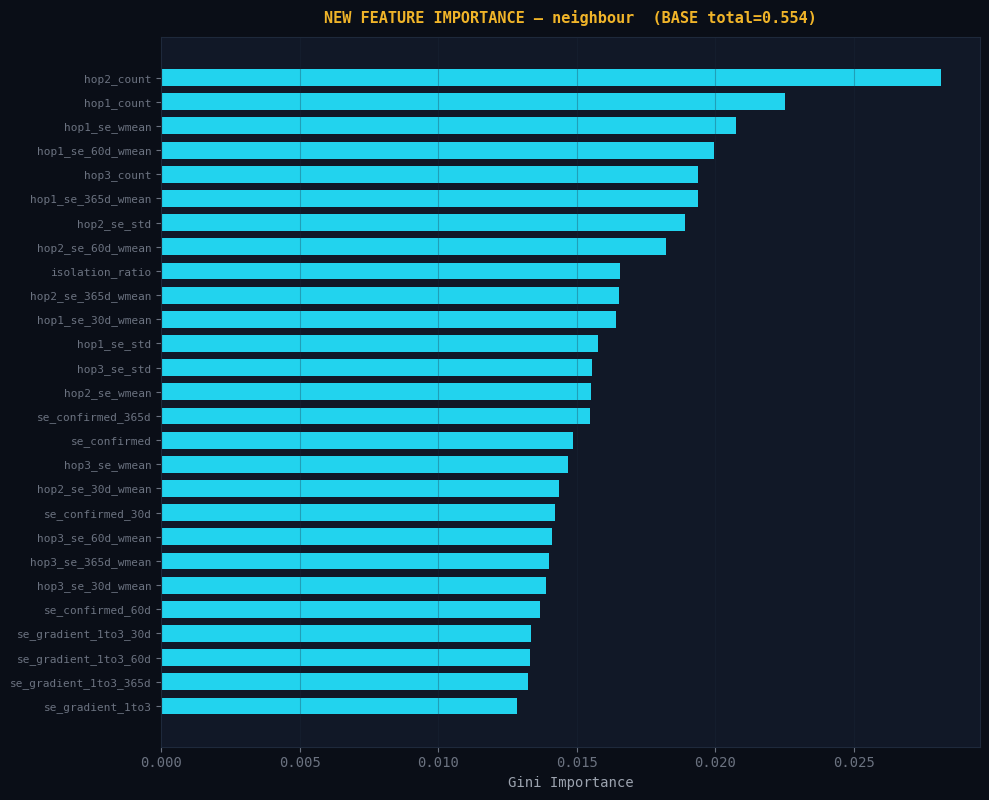

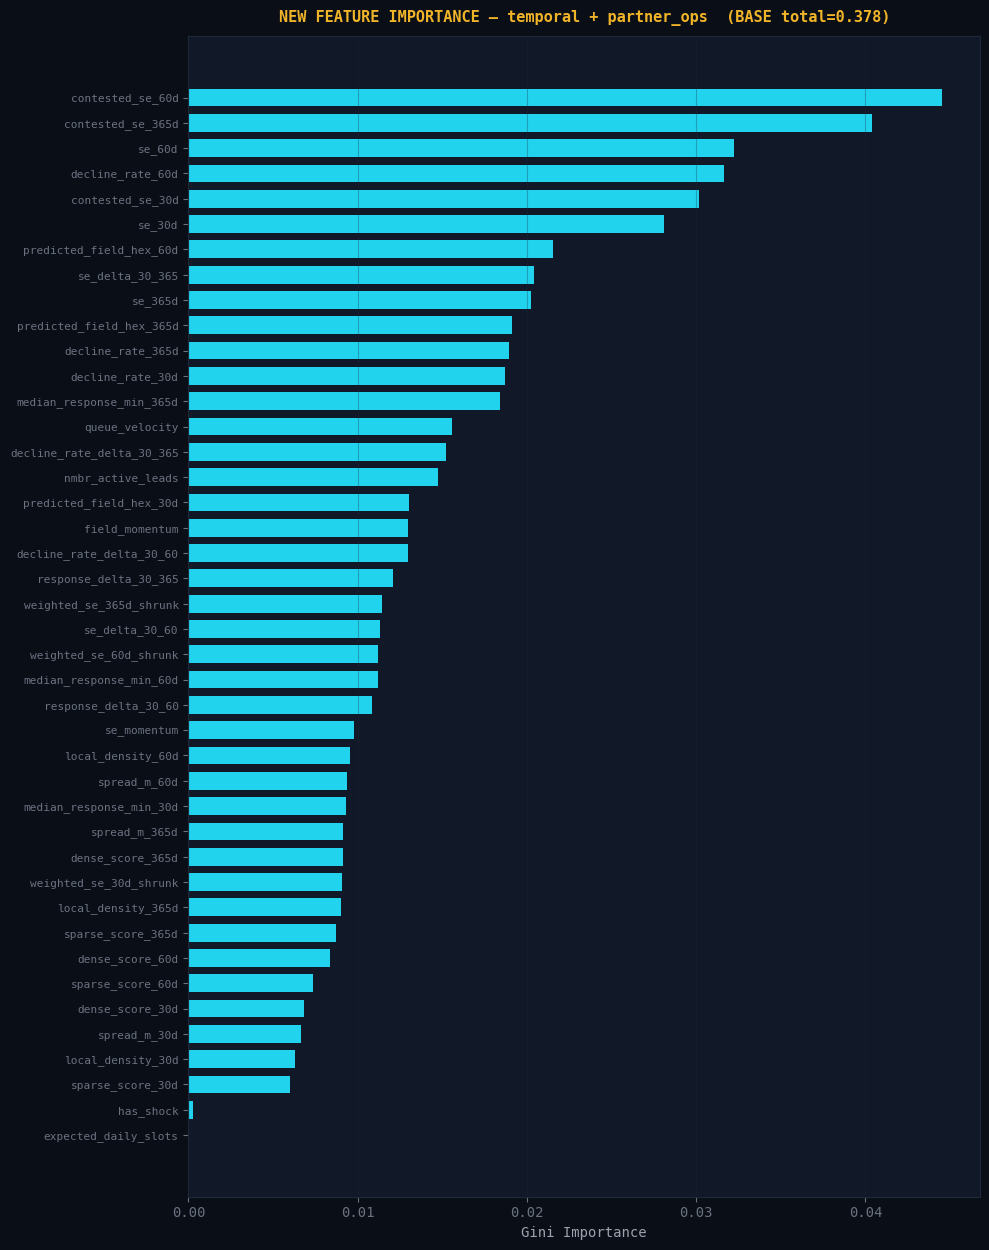

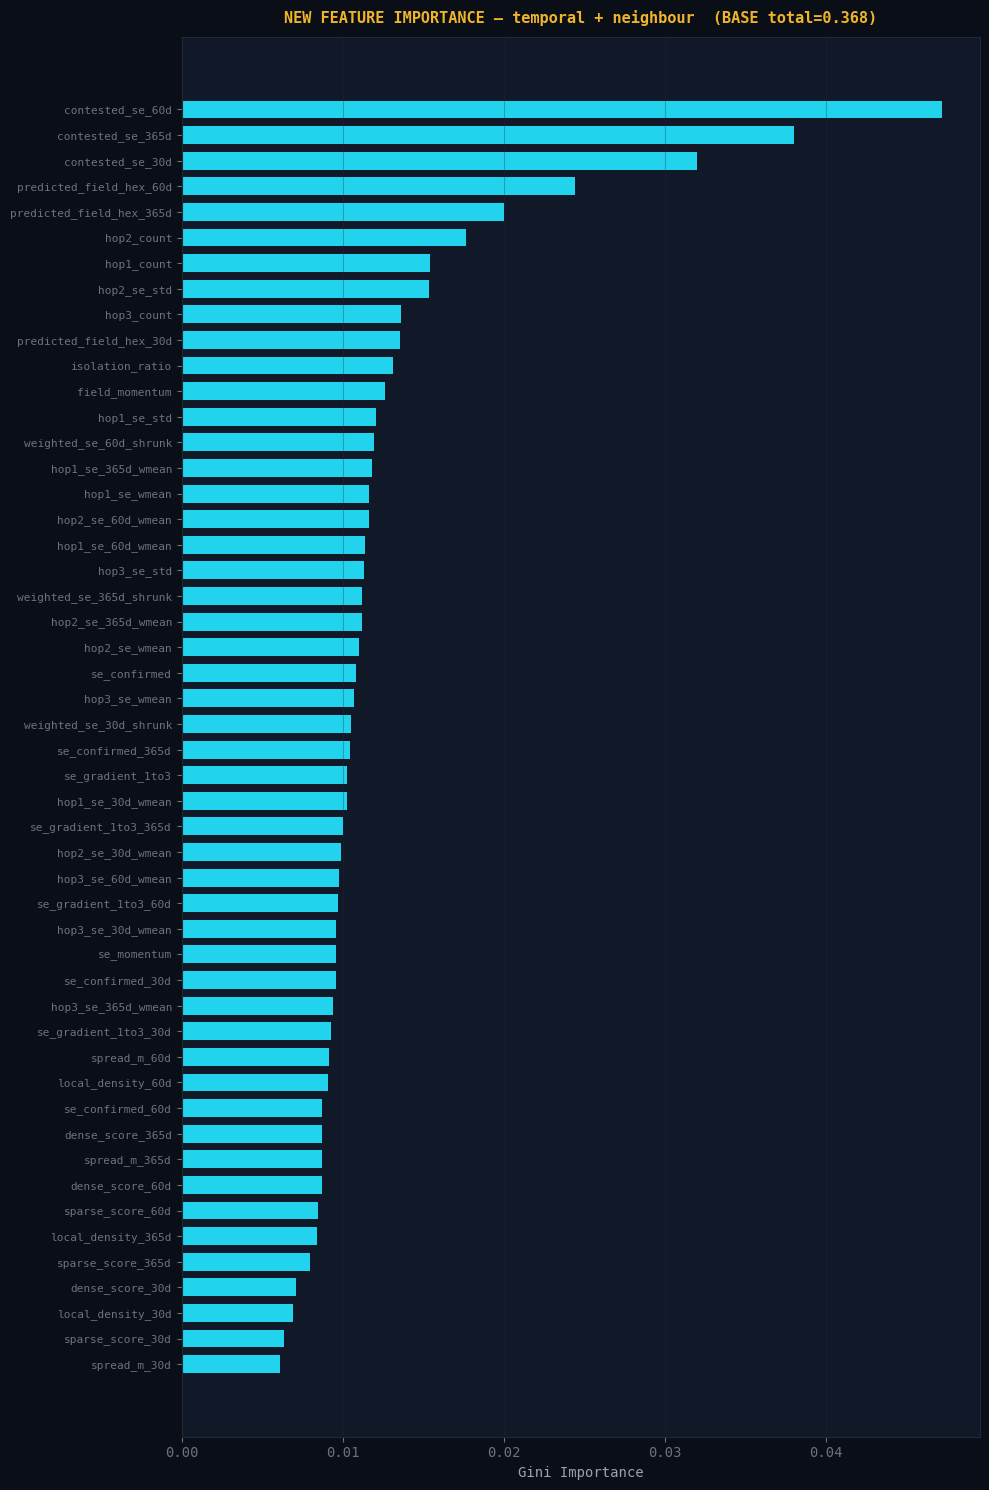

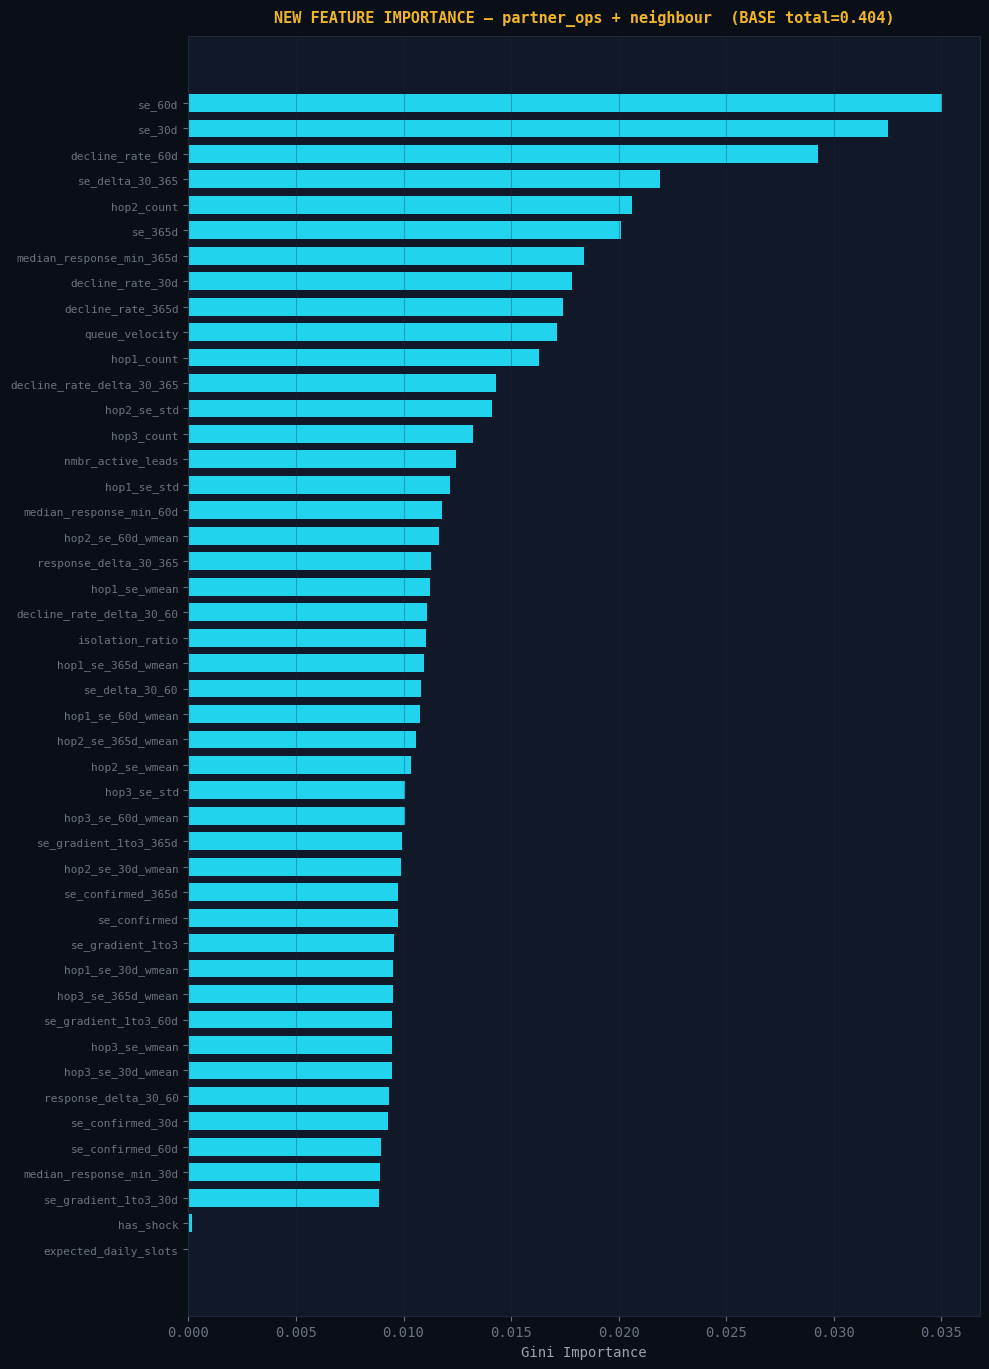

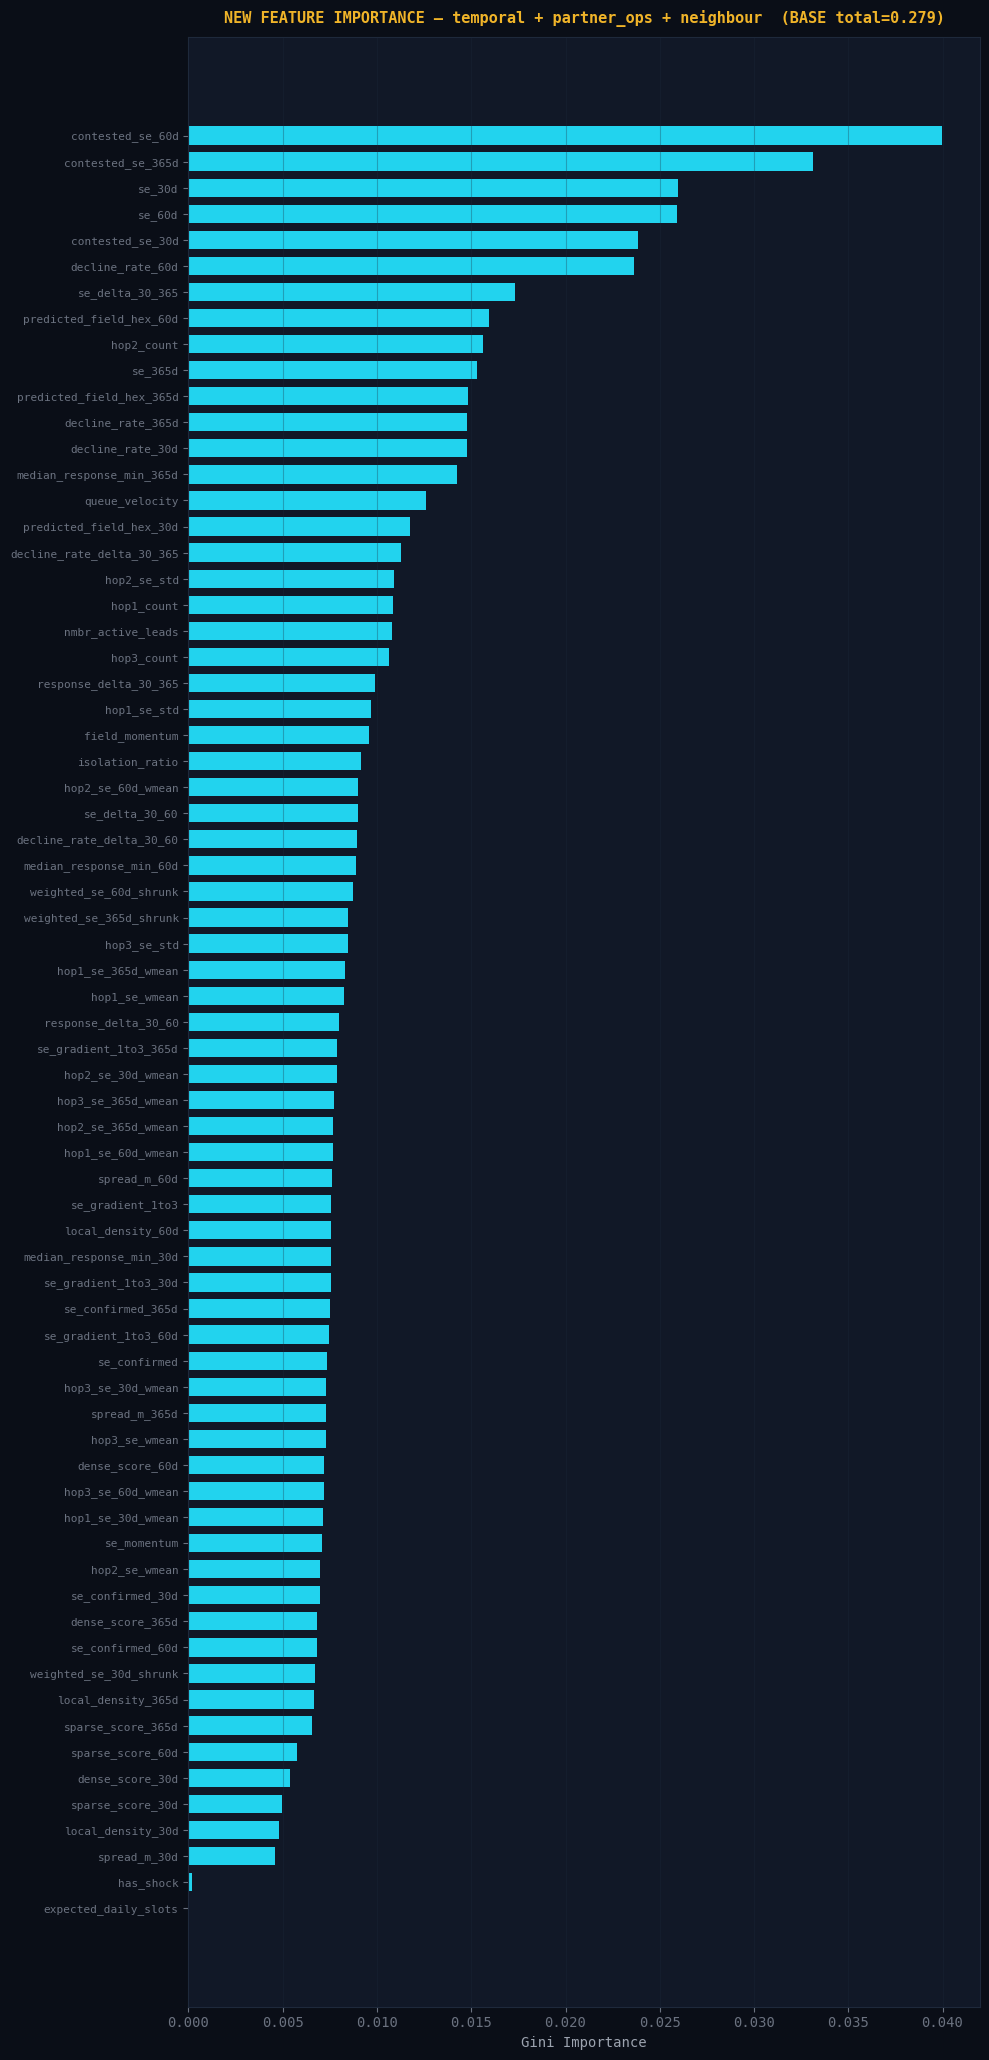

In [12]:
for exp_name in addon_exps:
    feat_list = EXPERIMENTS[exp_name]
    new_feats = [f for f in feat_list if f not in base_avail]
    if not new_feats:
        continue

    rf = RandomForestRegressor(**RF_PARAMS)
    rf.fit(X_train_full[feat_list], y_train)

    imp = pd.Series(rf.feature_importances_, index=feat_list)
    imp_new = imp[new_feats].sort_values(ascending=True)
    imp_base_total = imp[base_avail].sum()

    fig, ax = plt.subplots(figsize=(10, max(4, len(imp_new) * 0.3)))
    ax.barh(range(len(imp_new)), imp_new.values, color=CYAN, height=0.7, edgecolor="none")
    ax.set_yticks(range(len(imp_new)))
    ax.set_yticklabels(imp_new.index, fontsize=8)
    ax.set_xlabel("Gini Importance")
    short = exp_name.replace("BASE + ", "")
    ax.set_title(f"NEW FEATURE IMPORTANCE — {short}  (BASE total={imp_base_total:.3f})",
                 fontsize=11, fontweight="bold", color=AMBER, pad=10)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


## 11 · Verdict

In [13]:
print("=" * 110)
print("  FINAL DELTA SUMMARY (sorted by composite gain)")
print("=" * 110)
verdict = delta_df[delta_df["experiment"] != "BASE"].sort_values("Δ_composite", ascending=False)
print(verdict[["experiment", "model", "n_features", "Δ_auc", "Δ_gap_pp", "Δ_composite", "Δ_overfit", "mono"]].to_string(index=False))

print("\n  Key:")
print("  Δ_auc > 0 and Δ_overfit ≤ 0  →  clean gain")
print("  Δ_auc > 0 and Δ_overfit > 0   →  gain but adds overfit risk")
print("  Δ_auc ≤ 0                      →  no help (or hurts)")


  FINAL DELTA SUMMARY (sorted by composite gain)
                               experiment model  n_features  Δ_auc  Δ_gap_pp  Δ_composite  Δ_overfit  mono
BASE + temporal + partner_ops + neighbour    RF         104 0.0374     12.71        16.44      -0.95  True
            BASE + temporal + partner_ops    RF          77 0.0353     10.86        14.39      -1.94  True
           BASE + partner_ops + neighbour    RF          81 0.0369      9.94        13.63      -1.55 False
                       BASE + partner_ops    RF          54 0.0329      9.02        12.32      -2.73  True
BASE + temporal + partner_ops + neighbour   HGB         104 0.0341      7.91        11.33       0.69 False
                       BASE + partner_ops   HGB          54 0.0275      8.28        11.03       0.02 False
            BASE + temporal + partner_ops   HGB          77 0.0340      7.55        10.94       1.11 False
              BASE + temporal + neighbour    RF          85 0.0210      8.10        10.20      

In [15]:
out = verdict[["experiment", "model", "n_features", "Δ_auc", "Δ_gap_pp", "Δ_composite", "Δ_overfit"]].copy()

out.columns = [
    "Experiment", "Model", "# Features",
    "AUC Lift (%)", "Gap Improvement (pp)", "Composite Gain",
    "Overfit Change (pp)"
]

out["AUC Lift (%)"]          = (out["AUC Lift (%)"] * 100).round(2)
out["Gap Improvement (pp)"]  = out["Gap Improvement (pp)"].round(2)
out["Composite Gain"]        = out["Composite Gain"].round(3)
out["Overfit Change (pp)"]   = out["Overfit Change (pp)"].round(2)

out.to_csv("executive_summary.csv", index=False)
print("Saved executive_summary.csv")


Saved executive_summary.csv
